## Research 04 — Robustness Battery

### Why
A backtest that only looks good on one sample is content risk. This notebook stresses the
**equal-weight multi-horizon score** portfolio from `application.ipynb`.

### Tests
1. **Out-of-sample split** at 2015 (IS vs OOS)
2. **Universe** with and without BTC
3. **Cost ladder** 0 / 5 / 10 / 25 bps
4. **Vol targeting** on vs off (10% ann. target)

### How to read
Each section has a table, then a chart, then a one-line takeaway.
The final cell writes an honest verdict from the numbers.


In [1]:
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

from helpers.data_utils import load_monthly_panel
from helpers.signal_utils import trailing_return, sign_signal, multi_horizon_score
from helpers.backtest_utils import (
    position_from_signal, strategy_returns, compare_perf_stats, perf_stats,
    apply_transaction_costs, equal_weight_portfolio, volatility_target_returns,
    split_by_date,
)
from helpers.plot_utils import (
    plot_cumulative_comparison, plot_drawdown_comparison, plot_metric_bars,
)

FULL = ["SPY", "BIL", "IEF", "TLT", "GLD", "BTC-USD"]
NO_BTC = ["SPY", "BIL", "IEF", "TLT", "GLD"]
HORIZONS = [1, 3, 6, 12]
SPLIT = "2015-01-01"

def build_score_portfolio(tickers, cost_bps=10.0, vol_target=None):
    px_m, r_m = load_monthly_panel(tickers)
    signals = {k: sign_signal(trailing_return(r_m, k)) for k in HORIZONS}
    score = multi_horizon_score(signals)
    pos = position_from_signal(score, lag=1)
    gross = strategy_returns(pos, r_m)
    net = apply_transaction_costs(gross, pos, cost_bps=cost_bps)
    port = equal_weight_portfolio(net)
    bh = equal_weight_portfolio(r_m)
    if vol_target is not None:
        port = volatility_target_returns(port, target_ann_vol=vol_target)
    return bh, port, r_m

display(Markdown(
    f"Stress object: **EW multi-horizon score**, default cost **10 bps**, split at **{SPLIT}**."
))


Stress object: **EW multi-horizon score**, default cost **10 bps**, split at **2015-01-01**.

### 1–2. Sample split and BTC sensitivity

**Question A:** Does post-2015 look like pre-2015?
**Question B:** How much of the result is BTC's trend episodes?


Loaded SPY from cache: data/daily/SPY_adj_close.csv | rows=8350
Loaded BIL from cache: data/daily/BIL_adj_close.csv | rows=4741
Loaded IEF from cache: data/daily/IEF_adj_close.csv | rows=5957
Loaded TLT from cache: data/daily/TLT_adj_close.csv | rows=5957
Loaded GLD from cache: data/daily/GLD_adj_close.csv | rows=5375
Loaded BTC-USD from cache: data/daily/BTC-USD_adj_close.csv | rows=4216
Loaded SPY from cache: data/daily/SPY_adj_close.csv | rows=8350
Loaded BIL from cache: data/daily/BIL_adj_close.csv | rows=4741
Loaded IEF from cache: data/daily/IEF_adj_close.csv | rows=5957
Loaded TLT from cache: data/daily/TLT_adj_close.csv | rows=5957
Loaded GLD from cache: data/daily/GLD_adj_close.csv | rows=5375


#### Performance under sample / universe stress

,EW BH full,Score net full,Score IS <2015,Score OOS >=2015,EW BH no BTC,Score net no BTC
CAGR,0.1136,0.0684,0.0546,0.0944,0.0769,0.0405
Ann. Mean,0.1154,0.0708,0.0569,0.0964,0.0790,0.0426
Ann. Vol,0.1222,0.0954,0.0864,0.1099,0.0975,0.0751
Sharpe,0.9448,0.7428,0.6590,0.8768,0.8107,0.5667
Max Drawdown,-0.3867,-0.1764,-0.1764,-0.1229,-0.3867,-0.1764
Hit Rate,0.6216,0.5803,0.5560,0.6250,0.6291,0.5544


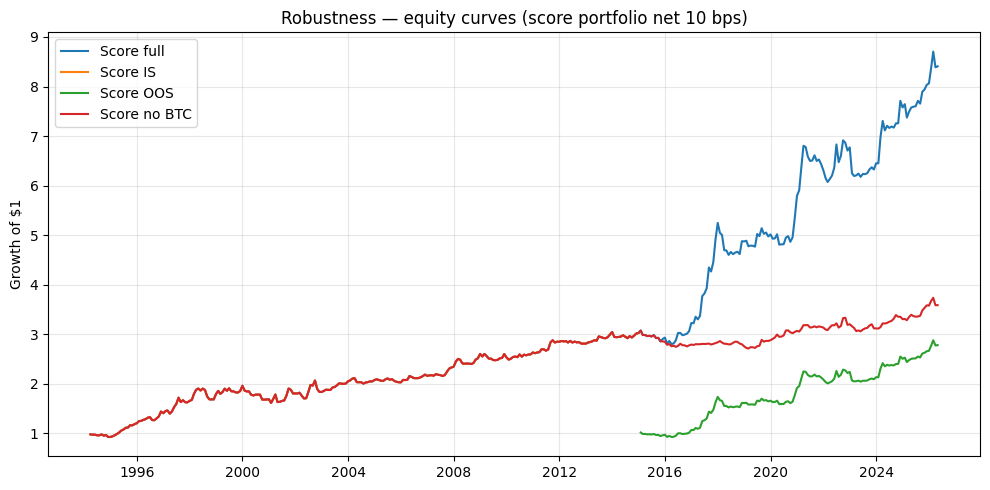

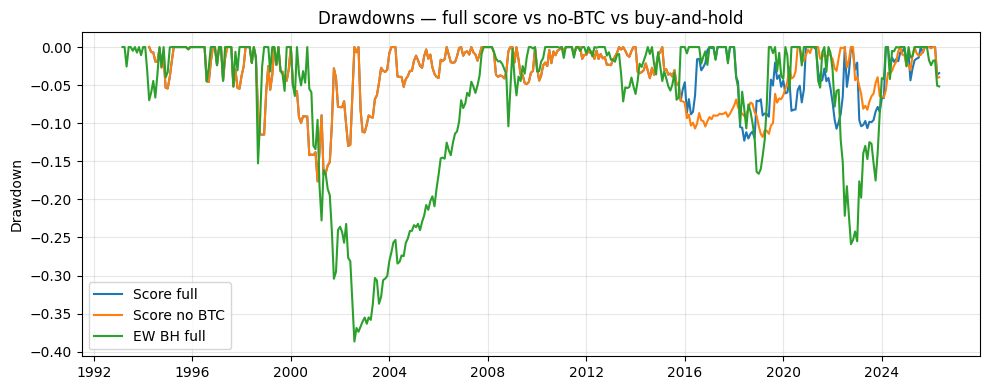

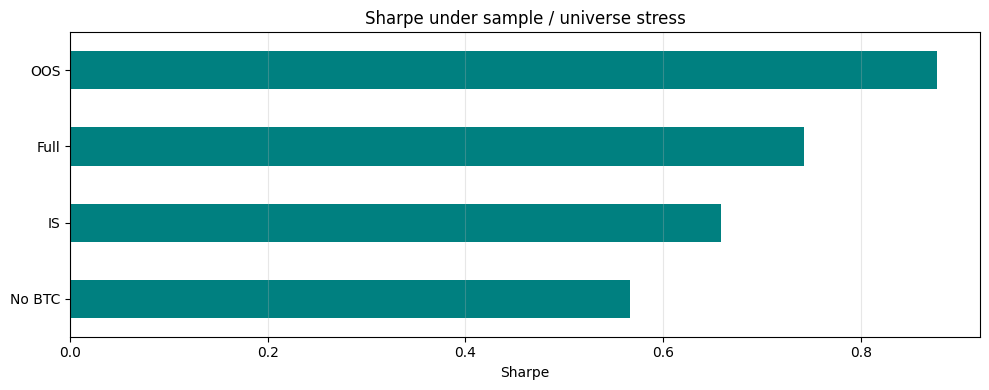

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Sharpe under sample / universe stress'}, xlabel='Sharpe'>)

In [2]:
bh, port, _ = build_score_portfolio(FULL, cost_bps=10)
p_is, p_oos = split_by_date(port, SPLIT)
bh_is, bh_oos = split_by_date(bh, SPLIT)
bh2, port2, _ = build_score_portfolio(NO_BTC, cost_bps=10)

split_stats = compare_perf_stats({
    "EW BH full": bh,
    "Score net full": port,
    "Score IS <2015": p_is,
    "Score OOS >=2015": p_oos,
    "EW BH no BTC": bh2,
    "Score net no BTC": port2,
})
display(Markdown("#### Performance under sample / universe stress"))
display(split_stats.round(4))

plot_cumulative_comparison(
    {
        "Score full": port,
        "Score IS": p_is,
        "Score OOS": p_oos,
        "Score no BTC": port2,
    },
    title="Robustness — equity curves (score portfolio net 10 bps)",
)
plot_drawdown_comparison(
    {"Score full": port, "Score no BTC": port2, "EW BH full": bh},
    title="Drawdowns — full score vs no-BTC vs buy-and-hold",
)

sharpes = pd.Series({
    "Full": perf_stats(port)["Sharpe"],
    "IS": perf_stats(p_is)["Sharpe"],
    "OOS": perf_stats(p_oos)["Sharpe"],
    "No BTC": perf_stats(port2)["Sharpe"],
})
plot_metric_bars(
    sharpes,
    title="Sharpe under sample / universe stress",
    ylabel="Sharpe",
    color="teal",
)


### 3–4. Cost ladder and vol targeting

**Question C:** At what cost does the edge look lame vs buy-and-hold?
**Question D:** Does 10% vol targeting stabilize the path?


Loaded SPY from cache: data/daily/SPY_adj_close.csv | rows=8350
Loaded BIL from cache: data/daily/BIL_adj_close.csv | rows=4741
Loaded IEF from cache: data/daily/IEF_adj_close.csv | rows=5957
Loaded TLT from cache: data/daily/TLT_adj_close.csv | rows=5957
Loaded GLD from cache: data/daily/GLD_adj_close.csv | rows=5375
Loaded BTC-USD from cache: data/daily/BTC-USD_adj_close.csv | rows=4216
Loaded SPY from cache: data/daily/SPY_adj_close.csv | rows=8350
Loaded BIL from cache: data/daily/BIL_adj_close.csv | rows=4741
Loaded IEF from cache: data/daily/IEF_adj_close.csv | rows=5957
Loaded TLT from cache: data/daily/TLT_adj_close.csv | rows=5957
Loaded GLD from cache: data/daily/GLD_adj_close.csv | rows=5375
Loaded BTC-USD from cache: data/daily/BTC-USD_adj_close.csv | rows=4216
Loaded SPY from cache: data/daily/SPY_adj_close.csv | rows=8350
Loaded BIL from cache: data/daily/BIL_adj_close.csv | rows=4741
Loaded IEF from cache: data/daily/IEF_adj_close.csv | rows=5957
Loaded TLT from cache: d

Loaded IEF from cache: data/daily/IEF_adj_close.csv | rows=5957
Loaded TLT from cache: data/daily/TLT_adj_close.csv | rows=5957
Loaded GLD from cache: data/daily/GLD_adj_close.csv | rows=5375
Loaded BTC-USD from cache: data/daily/BTC-USD_adj_close.csv | rows=4216


#### Cost sensitivity and vol target

,Score 0bps,Score 5bps,Score 10bps,Score 25bps,Score 10bps + VT10%
CAGR,0.0735,0.0710,0.0684,0.0609,0.1021
Ann. Mean,0.0756,0.0732,0.0708,0.0637,0.1052
Ann. Vol,0.0953,0.0953,0.0954,0.0955,0.1255
Sharpe,0.7932,0.7680,0.7428,0.6672,0.8385
Max Drawdown,-0.1705,-0.1734,-0.1764,-0.1851,-0.2034
Hit Rate,0.5959,0.5881,0.5803,0.5648,0.5882


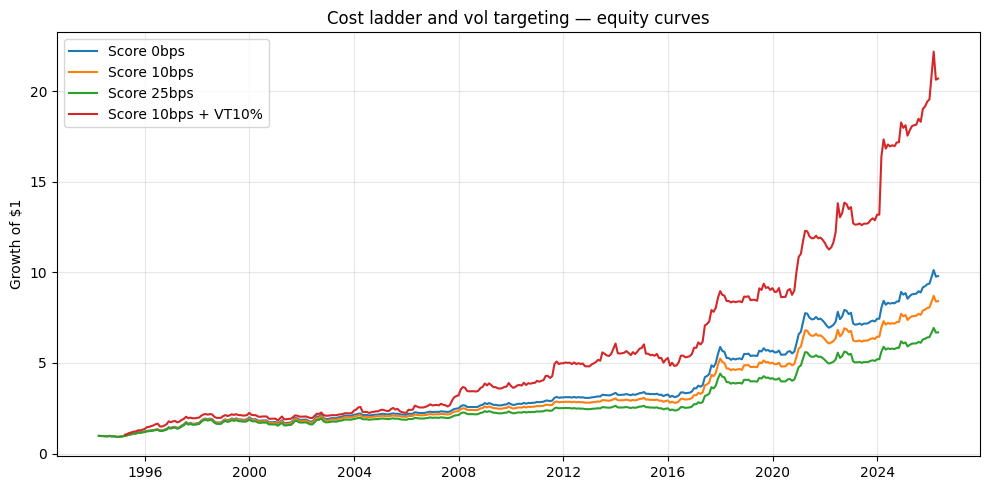

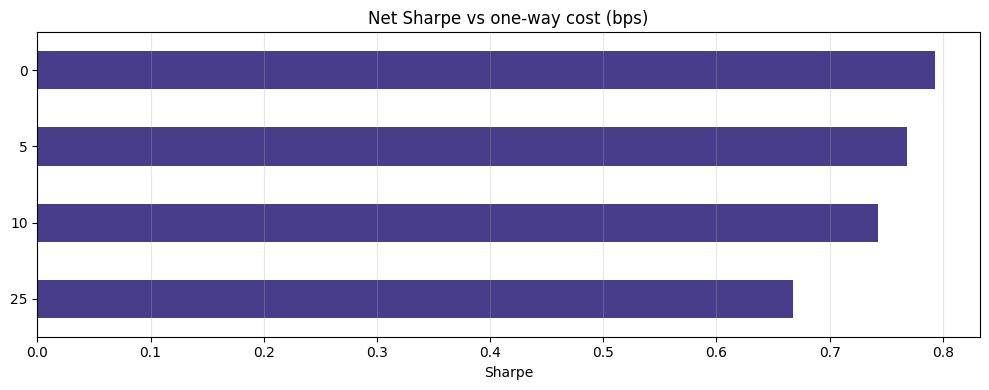

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Net Sharpe vs one-way cost (bps)'}, xlabel='Sharpe'>)

In [3]:
cost_map = {}
for bps in [0, 5, 10, 25]:
    _, p, _ = build_score_portfolio(FULL, cost_bps=bps)
    cost_map[f"Score {bps}bps"] = p

_, p_vt, _ = build_score_portfolio(FULL, cost_bps=10, vol_target=0.10)
cost_map["Score 10bps + VT10%"] = p_vt

cost_stats = compare_perf_stats(cost_map)
display(Markdown("#### Cost sensitivity and vol target"))
display(cost_stats.round(4))

plot_cumulative_comparison(
    {k: cost_map[k] for k in [
        "Score 0bps", "Score 10bps", "Score 25bps", "Score 10bps + VT10%"
    ]},
    title="Cost ladder and vol targeting — equity curves",
)

cost_sharpe = pd.Series({
    0: cost_stats.loc["Sharpe", "Score 0bps"],
    5: cost_stats.loc["Sharpe", "Score 5bps"],
    10: cost_stats.loc["Sharpe", "Score 10bps"],
    25: cost_stats.loc["Sharpe", "Score 25bps"],
})
plot_metric_bars(
    cost_sharpe,
    title="Net Sharpe vs one-way cost (bps)",
    ylabel="Sharpe",
    color="darkslateblue",
)


### Verdict


In [4]:
full_s = float(perf_stats(port)["Sharpe"])
is_s = float(perf_stats(p_is)["Sharpe"])
oos_s = float(perf_stats(p_oos)["Sharpe"])
nobtc_s = float(perf_stats(port2)["Sharpe"])
s0 = float(cost_stats.loc["Sharpe", "Score 0bps"])
s10 = float(cost_stats.loc["Sharpe", "Score 10bps"])
s25 = float(cost_stats.loc["Sharpe", "Score 25bps"])
vt_s = float(cost_stats.loc["Sharpe", "Score 10bps + VT10%"])

display(Markdown(f'''### Findings (auto-filled)
| Check | Result |
|-------|--------|
| OOS vs IS Sharpe | OOS **{oos_s:.2f}** vs IS **{is_s:.2f}** (full **{full_s:.2f}**) |
| Drop BTC | Sharpe falls to **{nobtc_s:.2f}** — crypto matters in this ETF set |
| Cost 0 → 10 → 25 bps | Sharpe **{s0:.2f} → {s10:.2f} → {s25:.2f}** |
| + 10% vol target | Sharpe **{vt_s:.2f}** |

### Honest read
- OOS holding up is good; it is **not** a license to overfit-celebrate.
- Say out loud that **BTC carries a lot of the diversified punch** here.
- Edge **softens with costs** but does not instantly vanish at 10 bps in this lab.
'''))


### Findings (auto-filled)
| Check | Result |
|-------|--------|
| OOS vs IS Sharpe | OOS **0.88** vs IS **0.66** (full **0.74**) |
| Drop BTC | Sharpe falls to **0.57** — crypto matters in this ETF set |
| Cost 0 → 10 → 25 bps | Sharpe **0.79 → 0.74 → 0.67** |
| + 10% vol target | Sharpe **0.84** |

### Honest read
- OOS holding up is good; it is **not** a license to overfit-celebrate.
- Say out loud that **BTC carries a lot of the diversified punch** here.
- Edge **softens with costs** but does not instantly vanish at 10 bps in this lab.
